### Lifestyle benchmarks

In [28]:
### load packages
import glob

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns
plt.rcParams.update({'font.size': 14})

In [29]:
### Download checkv provirus info
# !wget https://portal.nersc.gov/UHGV/mysql/tsv/checkv_contamination.tsv
# !wget https://portal.nersc.gov/UHGV/mysql/tsv/genomad_viral_stats.tsv

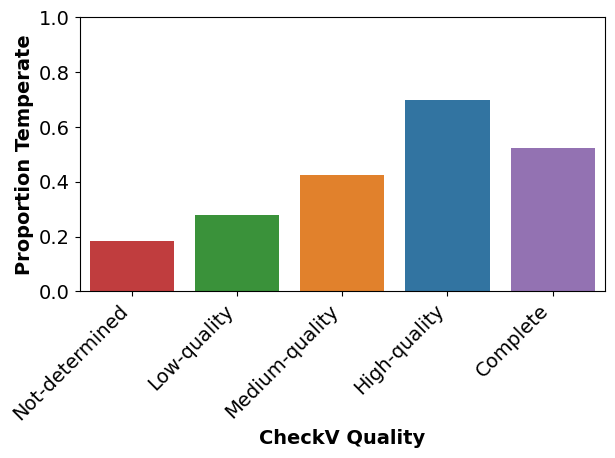

In [30]:
### UHGV prop temperate by completeness
conf_votus = (
    pl.read_csv('votus_metadata_extended.tsv', null_values='NULL', separator='\t', ignore_errors=True, columns=['uhgv_votu', 'bacphlip_temperate_score', 'uhgv_genome', 'checkv_quality', 'checkv_completeness', 'has_integrase', 'viral_confidence', 'lifestyle', 'lifestyle_evidence'])
)

checkv_provirus = (
    pl.read_csv('checkv_contamination.tsv', separator='\t', ignore_errors=True, null_values=['NULL'], columns=['contig_id', 'provirus', 'host_genes', 'host_length'])
        .rename({'contig_id':'uhgv_genome', 'provirus':'checkv_provirus'})
        .with_columns([
            pl.col('host_length').cast(pl.Float64)
        ])
)

genomad_provirus = (
    pl.read_csv('genomad_viral_stats.tsv', separator='\t', ignore_errors=True, columns=['contig_id', 'provirus'])
        .rename({'contig_id':'uhgv_genome', 'provirus':'genomad_provirus'})
)

contig2integrase = (
    pl.read_csv('../figure_s6/contig_to_integrase.tsv', separator='\t', ignore_errors=True)
)

combined = (
    conf_votus.join(checkv_provirus, on='uhgv_genome', how='left', coalesce=True).join(genomad_provirus, on='uhgv_genome', how='left', coalesce=True)
        .group_by(pl.col('checkv_quality'))
        .agg([
            (pl.col('lifestyle') != 'lytic').sum().alias('num_temperate'),
            pl.len().alias('total')
        ])
        .with_columns([
            (pl.col('num_temperate') / pl.col('total')).alias('prop_temperate')
        ])
)

# plot prop temperate by quality category
# make figure wider
sns.barplot(
    data=combined,
    x='checkv_quality',
    y='prop_temperate',
    hue='checkv_quality',
    order=['Not-determined', 'Low-quality', 'Medium-quality', 'High-quality', 'Complete']
)

plt.xlabel('CheckV Quality', fontdict={'fontweight': 'bold'})
plt.ylabel('Proportion Temperate', fontdict={'fontweight': 'bold'})
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [31]:
### Load UHVDB 5.1 metadata
UHVDB_META_PATH = (
    '/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/'
    'toolkit2/databases/uhvdb/5.1/uhvdb_metadata.tsv.gz'
)

uhvdb_meta = pl.read_csv(
    UHVDB_META_PATH,
    separator='\t',
    null_values=['NA', 'NULL', ''],
    columns=[
        'seq_name',
        'source_db',
        'hash',
        'seqhash_rep',
        'uhvdb_id',
        'topology',
        'provirus',
        'temperate',
        'virulent',
        'phrog_integrases',
        'phrog_integration_excision',
        'empathi_integration',
        'integration_status',
    ],
)
uhgv_uhvdb_meta = uhvdb_meta.filter(pl.col('source_db') == 'UHGV')

# one genome per unique sequence hash
uhgv_uhvdb_derep = uhgv_uhvdb_meta.filter(pl.col('seq_name') == pl.col('seqhash_rep'))
print(f'UHGV genomes: {uhgv_uhvdb_meta.height:,} -> {uhgv_uhvdb_derep.height:,} after hash dereplication')


UHGV genomes: 204,088 -> 181,979 after hash dereplication


In [32]:
### Join UHGV lifestyle annotations with UHVDB metadata
uhgv_classification = (
    pl.read_csv(
        'votus_metadata_extended.tsv',
        null_values='NULL',
        separator='\t',
        ignore_errors=True,
        columns=[
            'uhgv_votu',
            'bacphlip_temperate_score',
            'uhgv_genome',
            'checkv_quality',
            'checkv_completeness',
            'checkv_completeness_method',
            'has_integrase',
            'viral_confidence',
            'lifestyle',
            'lifestyle_evidence',
        ],
    )
)
uhgv_uhvdb_joined = (
    uhgv_classification.join(
        uhgv_uhvdb_meta,
        left_on='uhgv_genome',
        right_on='seq_name',
        how='inner',
    )
)
uhgv_uhvdb_joined


uhgv_genome,uhgv_votu,checkv_quality,checkv_completeness,checkv_completeness_method,viral_confidence,bacphlip_temperate_score,has_integrase,lifestyle,lifestyle_evidence,source_db,hash,seqhash_rep,uhvdb_id,topology,provirus,virulent,temperate,phrog_integrases,phrog_integration_excision,empathi_integration,integration_status
str,str,str,f64,str,str,f64,str,str,str,str,str,str,str,str,str,f64,f64,i64,i64,i64,str
"""UHGV-0004304""","""vOTU-062375""","""High-quality""",96.85,"""AAI-based""","""Confident""",0.9625,"""Yes""","""temperate""","""integrase""","""UHGV""","""34acf786c61698b93ecdfefcfc140f…","""UHGV-0004304""","""UHVDB-3""","""No terminal repeats""","""No""",0.0375,0.9625,1,2,4,"""unintegrated"""
"""UHGV-0004310""","""vOTU-084905""","""High-quality""",98.63,"""AAI-based""","""Confident""",0.188122,"""No""","""lytic""","""BACPHLIP""","""UHGV""","""747560b7bf32aa813cf5e12417a432…","""UHGV-0004310""","""UHVDB-4""","""No terminal repeats""","""No""",0.811878,0.188122,null,null,null,"""unintegrated"""
"""UHGV-0004308""","""vOTU-062377""","""High-quality""",99.9,"""AAI-based""","""Confident""",0.5125,"""No""","""temperate""","""BACPHLIP""","""UHGV""","""621f96f413d5c2bb19e60441e6c768…","""UHGV-0004308""","""UHVDB-5""","""No terminal repeats""","""No""",0.4875,0.5125,1,2,2,"""unintegrated"""
"""UHGV-0000154""","""vOTU-079754""","""High-quality""",95.88,"""AAI-based""","""Confident""",1.0,"""Yes""","""temperate""","""integrase""","""UHGV""","""6dd91d22b4b39c5699ee7c53ffba82…","""UHGV-0000154""","""UHVDB-8""","""No terminal repeats""","""No""",0.0,1.0,3,5,11,"""unintegrated"""
"""UHGV-0004610""","""vOTU-013570""","""High-quality""",96.7,"""AAI-based""","""Confident""",0.8,"""No""","""temperate""","""BACPHLIP""","""UHGV""","""b66c1e965d37f46bf0c3c94ea2d3f0…","""UHGV-0004610""","""UHVDB-11""","""No terminal repeats""","""No""",0.2,0.8,1,2,5,"""unintegrated"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""UHGV-2183490""","""vOTU-066254""","""High-quality""",99.76,"""AAI-based""","""Uncertain""",0.9875,"""No""","""temperate""","""BACPHLIP""","""UHGV""","""22e2424df65062fdd5f86559abb420…","""UHGV-2183490""","""UHVDB-181952""","""No terminal repeats""","""No""",0.0125,0.9875,2,3,6,"""unintegrated"""
"""UHGV-2188019""","""vOTU-083844""","""High-quality""",99.9,"""AAI-based""","""Uncertain""",1.0,"""No""","""temperate""","""BACPHLIP""","""UHGV""","""3d5c1d12855a3cd6288a7d4c3cc939…","""UHGV-2188019""","""UHVDB-181955""","""No terminal repeats""","""No""",0.0,1.0,1,1,5,"""unintegrated"""
"""UHGV-2206889""","""vOTU-082632""","""High-quality""",99.9,"""AAI-based""","""Uncertain""",0.9875,"""No""","""temperate""","""BACPHLIP""","""UHGV""","""208fe0cc981eb02f02dbb8a192291b…","""UHGV-2206889""","""UHVDB-181967""","""No terminal repeats""","""No""",0.0125,0.9875,1,2,3,"""unintegrated"""


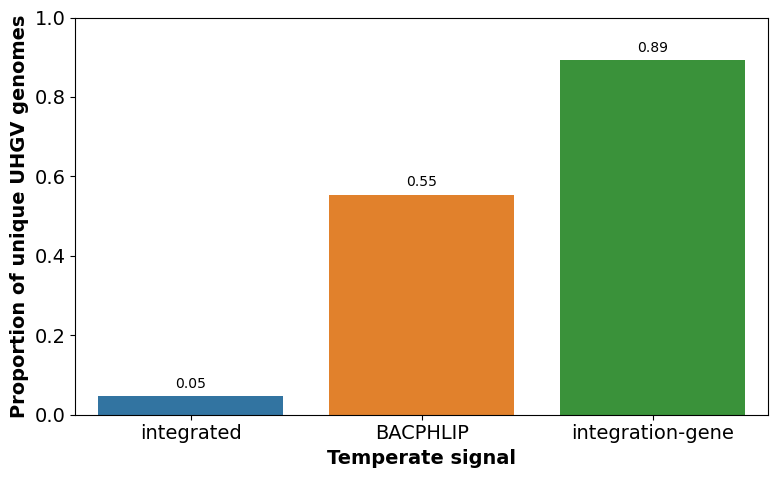

signal,count,proportion
str,i64,f64
"""integrated""",8362,0.04595
"""BACPHLIP""",100686,0.553284
"""integration-gene""",162482,0.892861


In [40]:
### Barplot: proportion of sequences having each temperate signal (hash-dereplicated UHGV genomes)
signal_order = [
    'integrated',
    'BACPHLIP',
    'integration-gene'
]

signal_exprs = {
    'integrated': (pl.col('integration_status') == 'integrated').fill_null(False),
    'BACPHLIP': (pl.col('temperate').cast(pl.Float64, strict=False) > 0.5).fill_null(False),
    'integration-gene': (
        (pl.col('phrog_integrases').cast(pl.Float64, strict=False) >= 1)
        | (pl.col('phrog_integration_excision').cast(pl.Float64, strict=False) >= 1)
        | (pl.col('empathi_integration').cast(pl.Float64, strict=False) >= 1)
    ).fill_null(False),
}

n_total = uhgv_uhvdb_derep.height
signal_records = []

for signal in signal_order:
    n_signal = uhgv_uhvdb_derep.filter(signal_exprs[signal]).height
    signal_records.append({
        'signal': signal,
        'count': n_signal,
        'proportion': n_signal / n_total,
    })

signal_props = pl.DataFrame(signal_records)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=signal_props.to_pandas(),
    x='signal',
    y='proportion',
    hue='signal',
    dodge=False,
    ax=ax
)

# Add proportions above each bar
for patch, prop in zip(ax.patches, signal_props['proportion'].to_list()):
    ax.annotate(
        f"{prop:.2f}",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha='center',
        va='bottom',
        xytext=(0, 4),
        textcoords='offset points',
        fontsize=10
    )

ax.set_xlabel('Temperate signal', fontdict={'fontweight': 'bold'})
ax.set_ylabel('Proportion of unique UHGV genomes', fontdict={'fontweight': 'bold'})
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

signal_props


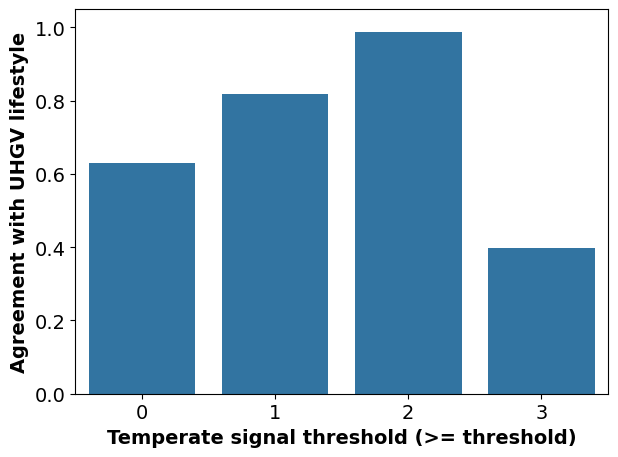

threshold,n_genomes,n_agree,agreement_prop
i64,i64,i64,f64
0,56055,35368,0.630952
1,56055,45838,0.817733
2,56055,55322,0.986924
3,56055,22261,0.397128


In [34]:
### Compare agreement between UHGV and UHVDB using thresholded temperate signal count
# Agreement is over all genomes present in both UHGV and UHVDB.
# UHVDB temperate if temperate_signal_count >= threshold; else lytic.
lifestyle_classifications = (
    uhgv_uhvdb_joined
        .with_columns([
            (
                (pl.col('integration_status') == 'integrated').fill_null(False).cast(pl.Int32) +
                ((pl.col('temperate') > 0.5)).fill_null(False).cast(pl.Int32) +
                ((pl.col('phrog_integration_excision') >= 1) | (pl.col('empathi_integration') >= 1)).fill_null(False).cast(pl.Int32)
            ).alias('temperate_signal_count'),
            (pl.col('lifestyle') != 'lytic').fill_null(False).alias('uhgv_temperate'),
        ])
)

max_signal_count = int(lifestyle_classifications['temperate_signal_count'].max())

agreement_by_threshold = pl.DataFrame([
    {
        'threshold': threshold,
        'n_genomes': lifestyle_classifications.height,
        'n_agree': (
            lifestyle_classifications
                .with_columns((pl.col('temperate_signal_count') >= threshold).alias('uhvdb_temperate_from_signals'))
                .with_columns((pl.col('uhgv_temperate') == pl.col('uhvdb_temperate_from_signals')).alias('agreement'))
                .filter(pl.col('agreement'))
                .height
        ),
        'agreement_prop': (
            lifestyle_classifications
                .with_columns((pl.col('temperate_signal_count') >= threshold).alias('uhvdb_temperate_from_signals'))
                .with_columns((pl.col('uhgv_temperate') == pl.col('uhvdb_temperate_from_signals')).alias('agreement'))
                .select(pl.col('agreement').mean())
                .item()
        )
    }
    for threshold in range(0, max_signal_count + 1)
])

fig, ax = plt.subplots()
sns.barplot(
    data=agreement_by_threshold.to_pandas(),
    x='threshold',
    y='agreement_prop',
    ax=ax
)

ax.set_xlabel('Temperate signal threshold (>= threshold)', fontdict={'fontweight': 'bold'})
ax.set_ylabel('Agreement with UHGV lifestyle', fontdict={'fontweight': 'bold'})
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

agreement_by_threshold


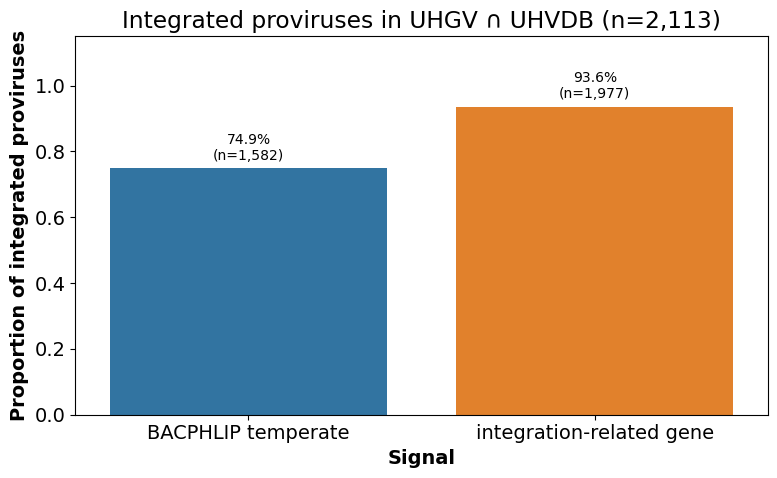

signal,n,proportion
str,i64,f64
"""BACPHLIP temperate""",1582,0.748699
"""integration-related gene""",1977,0.935637


In [35]:
### Among integrated proviruses: BACPHLIP temperate vs integration-related gene
integrated_proviruses = uhgv_uhvdb_joined.filter(pl.col('integration_status') == 'integrated')

has_bacphlip_temperate = (
    pl.col('bacphlip_temperate_score').cast(pl.Float64, strict=False) > 0.5
).fill_null(False)
has_integration_related_gene = (
    (pl.col('phrog_integrases').cast(pl.Float64, strict=False) >= 1)
    | (pl.col('phrog_integration_excision').cast(pl.Float64, strict=False) >= 1)
    | (pl.col('empathi_integration').cast(pl.Float64, strict=False) >= 1)
).fill_null(False)

n_integrated = integrated_proviruses.height
integrated_signal_props = pl.DataFrame([
    {
        'signal': 'BACPHLIP temperate',
        'n': integrated_proviruses.filter(has_bacphlip_temperate).height,
        'proportion': integrated_proviruses.filter(has_bacphlip_temperate).height / n_integrated,
    },
    {
        'signal': 'integration-related gene',
        'n': integrated_proviruses.filter(has_integration_related_gene).height,
        'proportion': integrated_proviruses.filter(has_integration_related_gene).height / n_integrated,
    },
])

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=integrated_signal_props.to_pandas(),
    x='signal',
    y='proportion',
    hue='signal',
    dodge=False,
    ax=ax,
)

for patch, row in zip(ax.patches, integrated_signal_props.iter_rows(named=True)):
    ax.annotate(
        f"{row['proportion']:.1%}\n(n={row['n']:,})",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha='center',
        va='bottom',
        xytext=(0, 4),
        textcoords='offset points',
        fontsize=10,
    )

ax.set_xlabel('Signal', fontdict={'fontweight': 'bold'})
ax.set_ylabel('Proportion of integrated proviruses', fontdict={'fontweight': 'bold'})
ax.set_ylim(0, 1.15)
ax.set_title(f'Integrated proviruses in UHGV ∩ UHVDB (n={n_integrated:,})')
plt.tight_layout()
plt.show()

integrated_signal_props


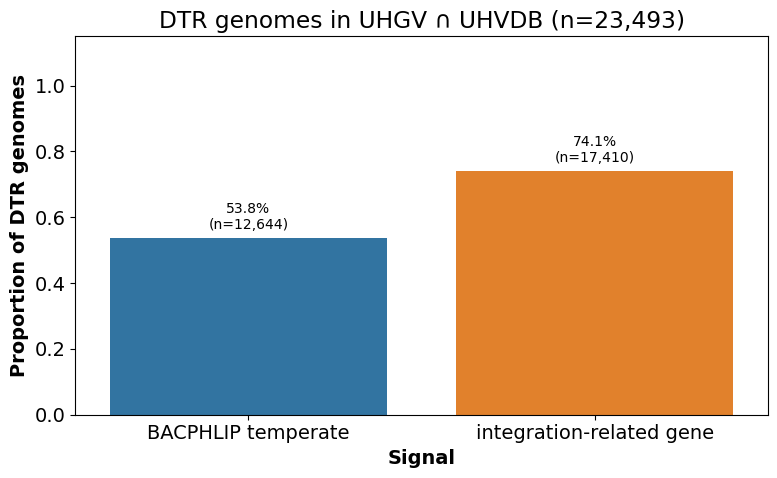

signal,n,proportion
str,i64,f64
"""BACPHLIP temperate""",12644,0.538203
"""integration-related gene""",17410,0.741072


In [36]:
### Among DTR genomes: BACPHLIP temperate vs integration-related gene
dtr_genomes = uhgv_uhvdb_joined.filter(pl.col('checkv_completeness_method') == 'DTR')

n_dtr = dtr_genomes.height
dtr_signal_props = pl.DataFrame([
    {
        'signal': 'BACPHLIP temperate',
        'n': dtr_genomes.filter(has_bacphlip_temperate).height,
        'proportion': dtr_genomes.filter(has_bacphlip_temperate).height / n_dtr,
    },
    {
        'signal': 'integration-related gene',
        'n': dtr_genomes.filter(has_integration_related_gene).height,
        'proportion': dtr_genomes.filter(has_integration_related_gene).height / n_dtr,
    },
])

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=dtr_signal_props.to_pandas(),
    x='signal',
    y='proportion',
    hue='signal',
    dodge=False,
    ax=ax,
)

for patch, row in zip(ax.patches, dtr_signal_props.iter_rows(named=True)):
    ax.annotate(
        f"{row['proportion']:.1%}\n(n={row['n']:,})",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha='center',
        va='bottom',
        xytext=(0, 4),
        textcoords='offset points',
        fontsize=10,
    )

ax.set_xlabel('Signal', fontdict={'fontweight': 'bold'})
ax.set_ylabel('Proportion of DTR genomes', fontdict={'fontweight': 'bold'})
ax.set_ylim(0, 1.15)
ax.set_title(f'DTR genomes in UHGV ∩ UHVDB (n={n_dtr:,})')
plt.tight_layout()
plt.show()

dtr_signal_props